# 🏥 Healthcare Predictive Analytics
## Disease Diagnosis Assistant — Milestones 1 & 2

**Project Goal:** Build a predictive model that helps doctors diagnose diseases based on patient symptoms.

---
**Dataset:** `Final_Augmented_dataset_Diseases_and_Symptoms.csv`  
- **246,945 patient records**
- **773 unique diseases**
- **377 symptom features** (binary: 0/1)

---
# 📦 MILESTONE 1: Data Collection, Exploration & Preprocessing

## 1.1 Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='Set2')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 1.2 Load Dataset

In [3]:
# Load the dataset 
df = pd.read_csv("D:\\depi\\project\\Final_Augmented_dataset_Diseases_and_Symptoms.csv")

print(f'📊 Dataset Shape: {df.shape}')
print(f'🦠 Unique Diseases: {df["diseases"].nunique()}')
print(f'🩺 Number of Symptom Features: {df.shape[1] - 1}')
print(f'\n🔍 First 3 rows:')
df.head(3)

📊 Dataset Shape: (246945, 378)
🦠 Unique Diseases: 773
🩺 Number of Symptom Features: 377

🔍 First 3 rows:


,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0


## 1.3 Data Exploration (EDA)
### 📂 Step 1: Data Loading & Initial Inspection
**Objective:** Load the processed binary dataset and perform a high-level inspection of its structure, including row/column counts, data types, and memory footprint. This step ensures the dataset is correctly formatted as a binary matrix (773 diseases and 377 symptom features).

In [4]:
print('='*60)
print('📋 DATASET INFO')
print('='*60)
print(f'Rows:    {df.shape[0]:,}')
print(f'Columns: {df.shape[1]:,}')
print(f'\nColumn data types:')
print(df.dtypes.value_counts())
print(f'\nMemory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

📋 DATASET INFO
Rows:    246,945
Columns: 378

Column data types:
int64     377
object      1
Name: count, dtype: int64

Memory usage: 761.2 MB


### 🔍 Step 2: Data Quality Assessment (Missing Values)
**Objective:** Verify the integrity of the dataset by identifying any missing or null values. In a predictive healthcare model, complete data is crucial for the accuracy of similarity calculations. This step checks every feature (symptom) and the target (disease) to ensure a 100% completion rate.

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing Count', ascending=False)

print('='*50)
print('🔍 MISSING VALUES SUMMARY')
print('='*50)
if missing.sum() == 0:
    print('✅ No missing values found! Dataset is complete.')
else:
    print(missing_df[missing_df['Missing Count'] > 0])

# Visualize missing values (if any)
cols_with_missing = missing_df[missing_df['Missing Count'] > 0]
if len(cols_with_missing) > 0:
    plt.figure(figsize=(10, 5))
    cols_with_missing['Missing %'].head(20).plot(kind='bar', color='salmon')
    plt.title('Top Columns with Missing Values')
    plt.ylabel('Missing %')
    plt.tight_layout()
    plt.show()
else:
    print('\n📊 No missing value chart needed — dataset is complete!')

🔍 MISSING VALUES SUMMARY
✅ No missing values found! Dataset is complete.

📊 No missing value chart needed — dataset is complete!


### 🦠 Step 3: Disease Prevalence & Distribution Analysis
**Objective:** Perform a statistical analysis of the disease labels to understand the frequency and distribution of records per condition. This step identifies the most common diseases in the dataset and checks for class imbalance. Understanding the "samples per disease" is vital for the reliability of the diagnostic engine's top-3 predictions.

🦠 DISEASE DISTRIBUTION STATISTICS
Total unique diseases: 773
Min samples per disease: 1
Max samples per disease: 1219
Mean samples per disease: 319.5

Top 10 most common diseases:
diseases
cystitis                          1219
vulvodynia                        1218
nose disorder                     1218
complex regional pain syndrome    1217
spondylosis                       1216
hypoglycemia                      1215
peripheral nerve disorder         1215
esophagitis                       1215
vaginal cyst                      1215
conjunctivitis due to allergy     1215
Name: count, dtype: int64


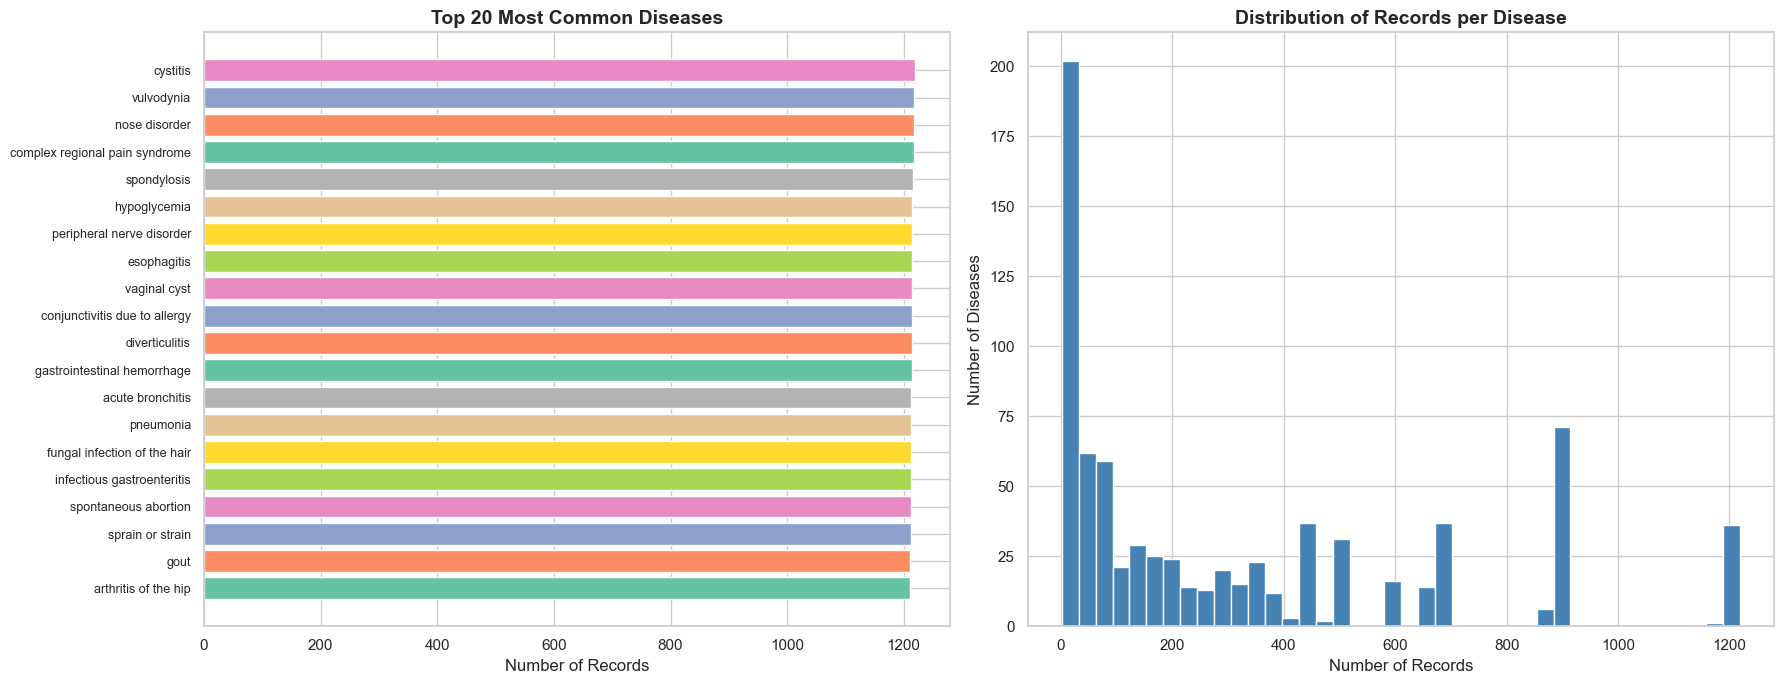

In [6]:
disease_counts = df['diseases'].value_counts()

print('='*60)
print('🦠 DISEASE DISTRIBUTION STATISTICS')
print('='*60)
print(f'Total unique diseases: {len(disease_counts)}')
print(f'Min samples per disease: {disease_counts.min()}')
print(f'Max samples per disease: {disease_counts.max()}')
print(f'Mean samples per disease: {disease_counts.mean():.1f}')
print(f'\nTop 10 most common diseases:')
print(disease_counts.head(10))

# Plot Top 20 Diseases
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Top 20 diseases
top20 = disease_counts.head(20)
axes[0].barh(top20.index[::-1], top20.values[::-1], color=sns.color_palette('Set2', 20))
axes[0].set_title('Top 20 Most Common Diseases', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Records')
axes[0].tick_params(axis='y', labelsize=9)

# Distribution of records per disease
axes[1].hist(disease_counts.values, bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('Distribution of Records per Disease', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Records')
axes[1].set_ylabel('Number of Diseases')

plt.tight_layout()
plt.show()

### 🩺 Step 4: Symptom Prevalence & Feature Importance Analysis
**Objective:** Analyze the frequency of individual symptoms across the entire dataset. This helps identify "Universal Symptoms" (common across many diseases) vs. "Specific Symptoms" (rare and highly indicative of certain conditions). Identifying symptoms with zero frequency is also crucial for feature selection, as they provide no predictive value for the model.

🩺 SYMPTOM FREQUENCY ANALYSIS
Total symptoms: 377

Top 15 most frequent symptoms:
sharp abdominal pain                13.08
vomiting                            11.29
headache                            10.01
cough                                9.84
sharp chest pain                     9.73
nausea                               9.59
back pain                            8.83
shortness of breath                  8.64
fever                                8.26
dizziness                            6.99
abnormal appearing skin              6.65
nasal congestion                     6.56
leg pain                             6.56
skin swelling                        6.14
depressive or psychotic symptoms     6.10

Bottom 5 rarest symptoms:
underweight                0.0
discharge in stools        0.0
elbow cramps or spasms     0.0
infrequent menstruation    0.0
neck weakness              0.0


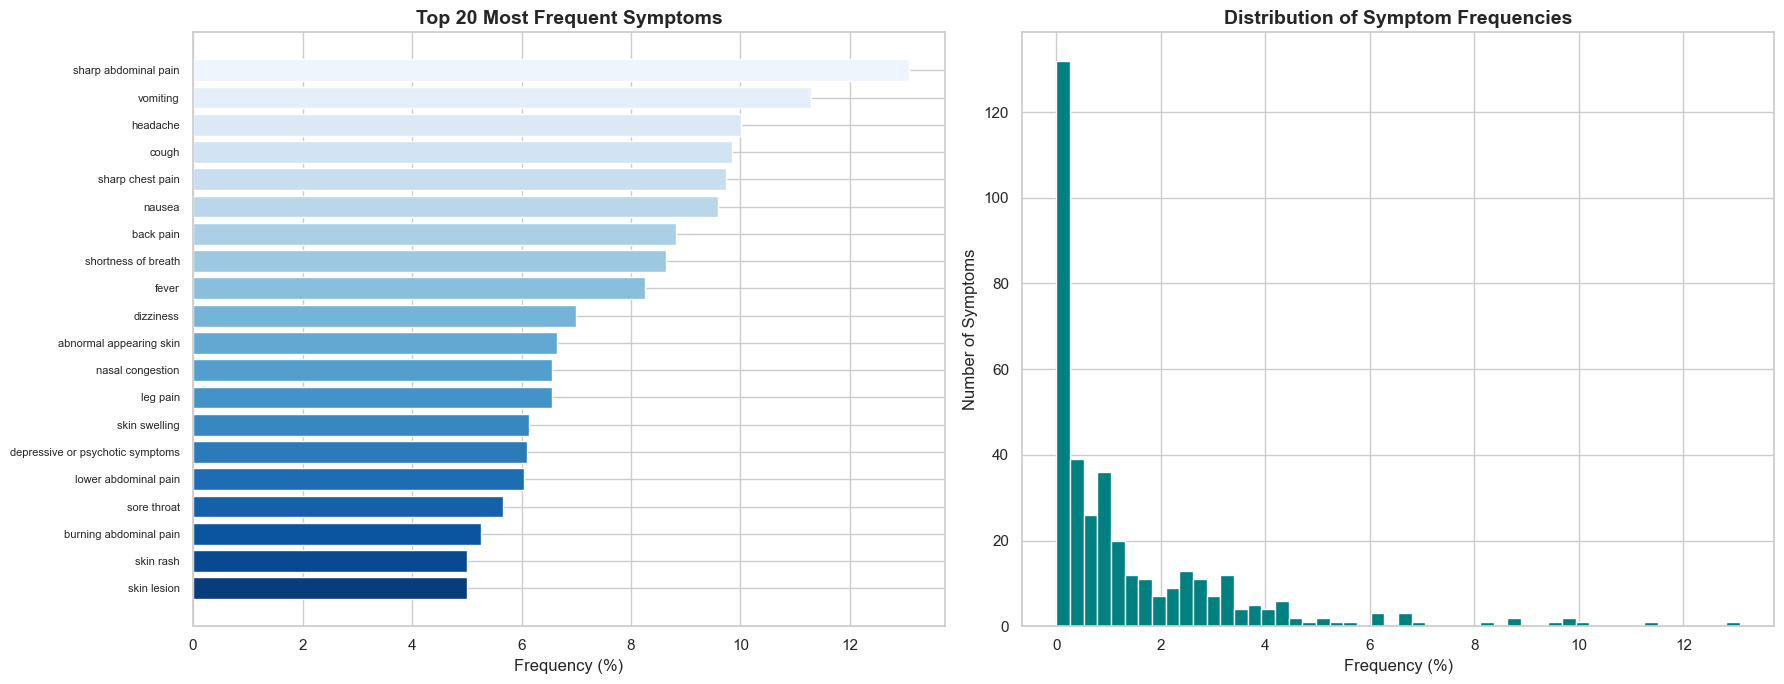

In [7]:
# Get symptom columns (all columns except 'diseases')
symptom_cols = df.columns[1:].tolist()

# Calculate frequency of each symptom across all records
symptom_freq = df[symptom_cols].sum().sort_values(ascending=False)
symptom_freq_pct = (symptom_freq / len(df) * 100).round(2)

print('='*60)
print('🩺 SYMPTOM FREQUENCY ANALYSIS')
print('='*60)
print(f'Total symptoms: {len(symptom_cols)}')
print(f'\nTop 15 most frequent symptoms:')
print(symptom_freq_pct.head(15).to_string())
print(f'\nBottom 5 rarest symptoms:')
print(symptom_freq_pct.tail(5).to_string())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Top 20 symptoms
top_symptoms = symptom_freq_pct.head(20)
axes[0].barh(top_symptoms.index[::-1], top_symptoms.values[::-1],
             color=sns.color_palette('Blues_r', 20))
axes[0].set_title('Top 20 Most Frequent Symptoms', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Frequency (%)')
axes[0].tick_params(axis='y', labelsize=8)

# Symptom frequency distribution
axes[1].hist(symptom_freq_pct.values, bins=50, color='teal', edgecolor='white')
axes[1].set_title('Distribution of Symptom Frequencies', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Frequency (%)')
axes[1].set_ylabel('Number of Symptoms')

plt.tight_layout()
plt.show()

### 📊 Step 5: Symptom Density & Complexity Analysis
**Objective:** Measure the "Symptom Density" per patient record and per disease category. By calculating the total number of active symptoms for each case, we gain insights into the complexity of different medical conditions. This analysis helps in understanding whether certain diseases are consistently more "symptom-heavy" than others, which is vital for fine-tuning the diagnostic engine's sensitivity.

📊 SYMPTOMS PER DISEASE ANALYSIS
Average symptoms per patient: 5.33
Min symptoms in a record: 1
Max symptoms in a record: 12

Top 10 diseases with most symptoms on average:
diseases
hiatal hernia                         6.300221
temporary or benign blood in urine    6.264214
anxiety                               6.095159
concussion                            6.090680
obstructive sleep apnea (osa)         6.086120
dental caries                         6.079325
injury to the leg                     6.076285
strep throat                          6.073554
acute bronchitis                      6.070899
marijuana abuse                       6.066942
Name: symptom_count, dtype: float64


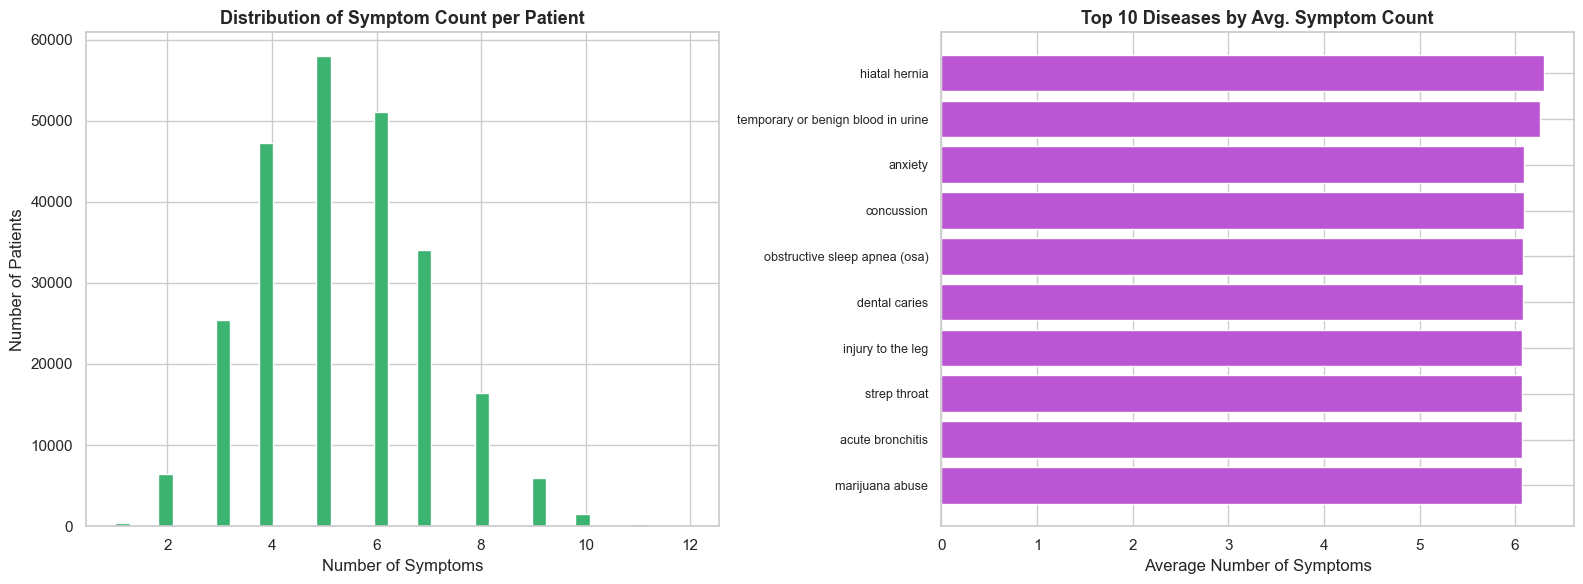

In [8]:
# Average number of symptoms per disease
symptom_cols = df.columns[1:].tolist()
df['symptom_count'] = df[symptom_cols].sum(axis=1)

avg_symptoms_per_disease = df.groupby('diseases')['symptom_count'].mean().sort_values(ascending=False)

print('='*60)
print('📊 SYMPTOMS PER DISEASE ANALYSIS')
print('='*60)
print(f'Average symptoms per patient: {df["symptom_count"].mean():.2f}')
print(f'Min symptoms in a record: {df["symptom_count"].min()}')
print(f'Max symptoms in a record: {df["symptom_count"].max()}')
print(f'\nTop 10 diseases with most symptoms on average:')
print(avg_symptoms_per_disease.head(10))

# Boxplot of symptom count distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(df['symptom_count'], bins=40, color='mediumseagreen', edgecolor='white')
axes[0].set_title('Distribution of Symptom Count per Patient', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Symptoms')
axes[0].set_ylabel('Number of Patients')

top10_disease_symptoms = avg_symptoms_per_disease.head(10)
axes[1].barh(top10_disease_symptoms.index[::-1], top10_disease_symptoms.values[::-1],
             color='mediumorchid')
axes[1].set_title('Top 10 Diseases by Avg. Symptom Count', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Number of Symptoms')
axes[1].tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.show()

### 📈 Step 6: Descriptive Statistical Profiling (Symptom Features)
**Objective:** Generate a detailed statistical summary for the binary symptom features. Since all feature values are strictly 0 or 1, the calculated **mean** directly represents the **Prevalence Rate** (the probability of a symptom appearing in the dataset). This step provides a quantitative baseline for understanding symptom distribution and helps identify dominant features in the predictive model.

In [9]:
print('='*60)
print('📈 DESCRIPTIVE STATISTICS (Symptom Features)')
print('='*60)

# Since all symptom cols are binary (0/1), mean = prevalence rate
desc = df[symptom_cols].describe().T
desc['prevalence_%'] = (desc['mean'] * 100).round(2)
print(desc[['mean', 'std', 'min', 'max', 'prevalence_%']].head(20))

📈 DESCRIPTIVE STATISTICS (Symptom Features)
                                      mean       std  min  max  prevalence_%
anxiety and nervousness           0.039235  0.194155  0.0  1.0          3.92
depression                        0.042746  0.202285  0.0  1.0          4.27
shortness of breath               0.086440  0.281014  0.0  1.0          8.64
depressive or psychotic symptoms  0.061001  0.239333  0.0  1.0          6.10
sharp chest pain                  0.097252  0.296302  0.0  1.0          9.73
dizziness                         0.069943  0.255051  0.0  1.0          6.99
insomnia                          0.039410  0.194568  0.0  1.0          3.94
abnormal involuntary movements    0.040572  0.197296  0.0  1.0          4.06
chest tightness                   0.037871  0.190884  0.0  1.0          3.79
palpitations                      0.024876  0.155747  0.0  1.0          2.49
irregular heartbeat               0.025111  0.156462  0.0  1.0          2.51
breathing fast                  

### 🛠️ Step 7: Data Imputation & Cleaning Strategy
**Objective:** Establish a robust protocol for handling missing values should they arise during data stream updates. In a binary healthcare dataset, a missing symptom value is logically treated as "0" (Symptom Absent), while a missing disease label is unrecoverable and must be removed. This step ensures that the final dataset is mathematically sound and ready for high-performance predictive analytics.

In [10]:
# Check for missing values
total_missing = df.isnull().sum().sum()
print(f'Total missing values: {total_missing}')

if total_missing > 0:
    # For binary symptom columns: fill with 0 (symptom absent)
    df[symptom_cols] = df[symptom_cols].fillna(0)
    # For 'diseases' column: drop rows with missing disease label
    df.dropna(subset=['diseases'], inplace=True)
    print(f'✅ Missing values handled. New shape: {df.shape}')
else:
    print('✅ No missing values — no imputation needed!')

Total missing values: 0
✅ No missing values — no imputation needed!


### 🔢 Step 8: Target Variable Encoding (Label Encoding)
**Objective:** Transform the categorical disease names into a numerical format using `LabelEncoder`. Machine learning algorithms and similarity metrics perform better with numerical identifiers. This step maps each of the **773 unique diseases** to a specific integer, while maintaining a `label_map` dictionary to ensure we can decode the numbers back to original disease names for the final user output.

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['disease_encoded'] = le.fit_transform(df['diseases'])

print('✅ Disease labels encoded!')
print(f'\nNumber of unique disease classes: {len(le.classes_)}')
print('\nSample encoding:')
for disease, code in zip(le.classes_[:5], range(5)):
    print(f'  {disease!r:45} → {code}')

# Save label encoder mapping
label_map = {i: name for i, name in enumerate(le.classes_)}
print(f'\n📌 Encoding map stored in `label_map` dict.')

✅ Disease labels encoded!

Number of unique disease classes: 773

Sample encoding:
  'abdominal aortic aneurysm'                   → 0
  'abdominal hernia'                            → 1
  'abscess of nose'                             → 2
  'abscess of the lung'                         → 3
  'abscess of the pharynx'                      → 4

📌 Encoding map stored in `label_map` dict.


### ⚖️ Step 9: Data Normalization & Binary Consistency Check
**Objective:** Perform a strict validation of the symptom feature values. This step ensures that every cell in the symptom matrix contains only **0 (Absent)** or **1 (Present)**. By using the `clip(0, 1)` function, we handle any potential outliers or noise that might have been introduced during data augmentation, ensuring the dataset is mathematically compatible with binary classification and similarity algorithms.

In [12]:
# Check unique values in symptom columns
unique_vals = set()
for col in symptom_cols:
    unique_vals.update(df[col].unique())

print(f'Unique values found in symptom columns: {sorted(unique_vals)}')

# Ensure binary (clip to 0-1)
df[symptom_cols] = df[symptom_cols].clip(0, 1).astype(int)
print('✅ All symptom features confirmed as binary (0/1)')

Unique values found in symptom columns: [0, 1]
✅ All symptom features confirmed as binary (0/1)


### 📉 Step 10: Statistical Outlier Detection (Symptom Complexity)
**Objective:** Identify anomalous patient records using the Interquartile Range (IQR) method on the `symptom_count` feature. In this context, "outliers" represent patients with an unusually low (minimalist) or unusually high (complex) number of symptoms compared to the general population. Monitoring these records is essential for ensuring that the predictive model is not skewed by extreme cases or potential data entry errors.

Symptom count — Q1: 4, Q3: 6, IQR: 2
Bounds: [1, 9]
Records outside bounds: 1,773 (0.72%)


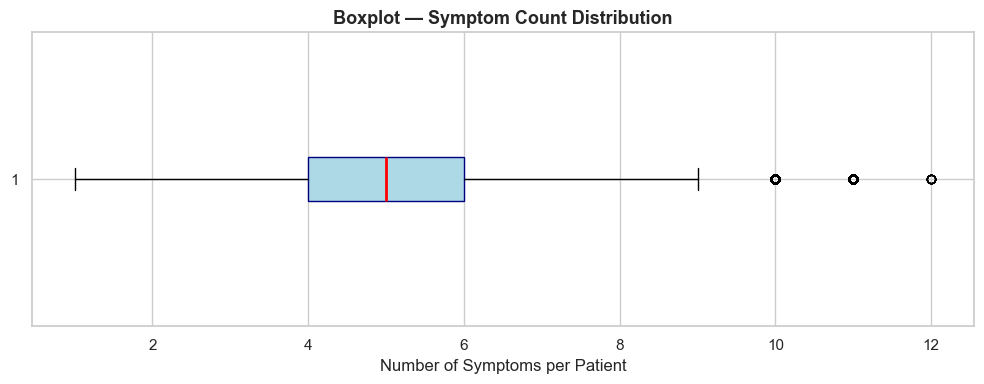

In [13]:
# For binary features, outliers = patients with unusually high/low symptom counts
Q1 = df['symptom_count'].quantile(0.25)
Q3 = df['symptom_count'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['symptom_count'] < lower_bound) | (df['symptom_count'] > upper_bound)]
print(f'Symptom count — Q1: {Q1:.0f}, Q3: {Q3:.0f}, IQR: {IQR:.0f}')
print(f'Bounds: [{lower_bound:.0f}, {upper_bound:.0f}]')
print(f'Records outside bounds: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)')

# Boxplot
fig, ax = plt.subplots(figsize=(10, 4))
ax.boxplot(df['symptom_count'], vert=False, patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='navy'),
           medianprops=dict(color='red', linewidth=2))
ax.set_xlabel('Number of Symptoms per Patient')
ax.set_title('Boxplot — Symptom Count Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 💾 Step 11: Final Dataset Export & Integrity Verification
**Objective:** Finalize the data preprocessing pipeline by exporting the cleaned binary matrix to a persistent CSV file. Before saving, all auxiliary columns used for exploratory analysis (such as `symptom_count` and `disease_encoded`) are removed to maintain a pure feature-target structure. This ensures the output file is streamlined for model training and high-speed diagnostic similarity searches.

In [14]:
# Save cleaned dataset (drop helper columns before saving)
#df_clean = df.drop(columns=['symptom_count', 'disease_encoded'])
#df_clean.to_csv('Cleaned_Disease_Symptoms.csv', index=False)

#print('✅ Cleaned dataset saved as: Cleaned_Disease_Symptoms.csv')
#print(f'   Shape: {df_clean.shape}')
#print(f'   Missing values: {df_clean.isnull().sum().sum()}')

## ✅ Milestone 1 Summary

| Item | Value |
|------|-------|
| Total records | 246,945 |
| Unique diseases | 773 |
| Symptom features | 377 |
| Missing values | 0 |
| Feature type | Binary (0/1) |
| Target encoding | LabelEncoder applied |
| Output | `Cleaned_Disease_Symptoms.csv` |

---
# 📊 MILESTONE 2: Data Analysis and Visualization

### 🔗 Step 12: Symptom Correlation & Co-occurrence Analysis
**Objective:** Explore the statistical relationships between the top 25 most frequent symptoms to identify common clinical clusters. By generating a correlation matrix and visualizing it with a masked heatmap, we can pinpoint symptoms that frequently co-occur (e.g., Nausea and Vomiting). Understanding these associations is vital for the diagnostic engine, as it helps identify characteristic "Symptom Signatures" for various medical conditions.

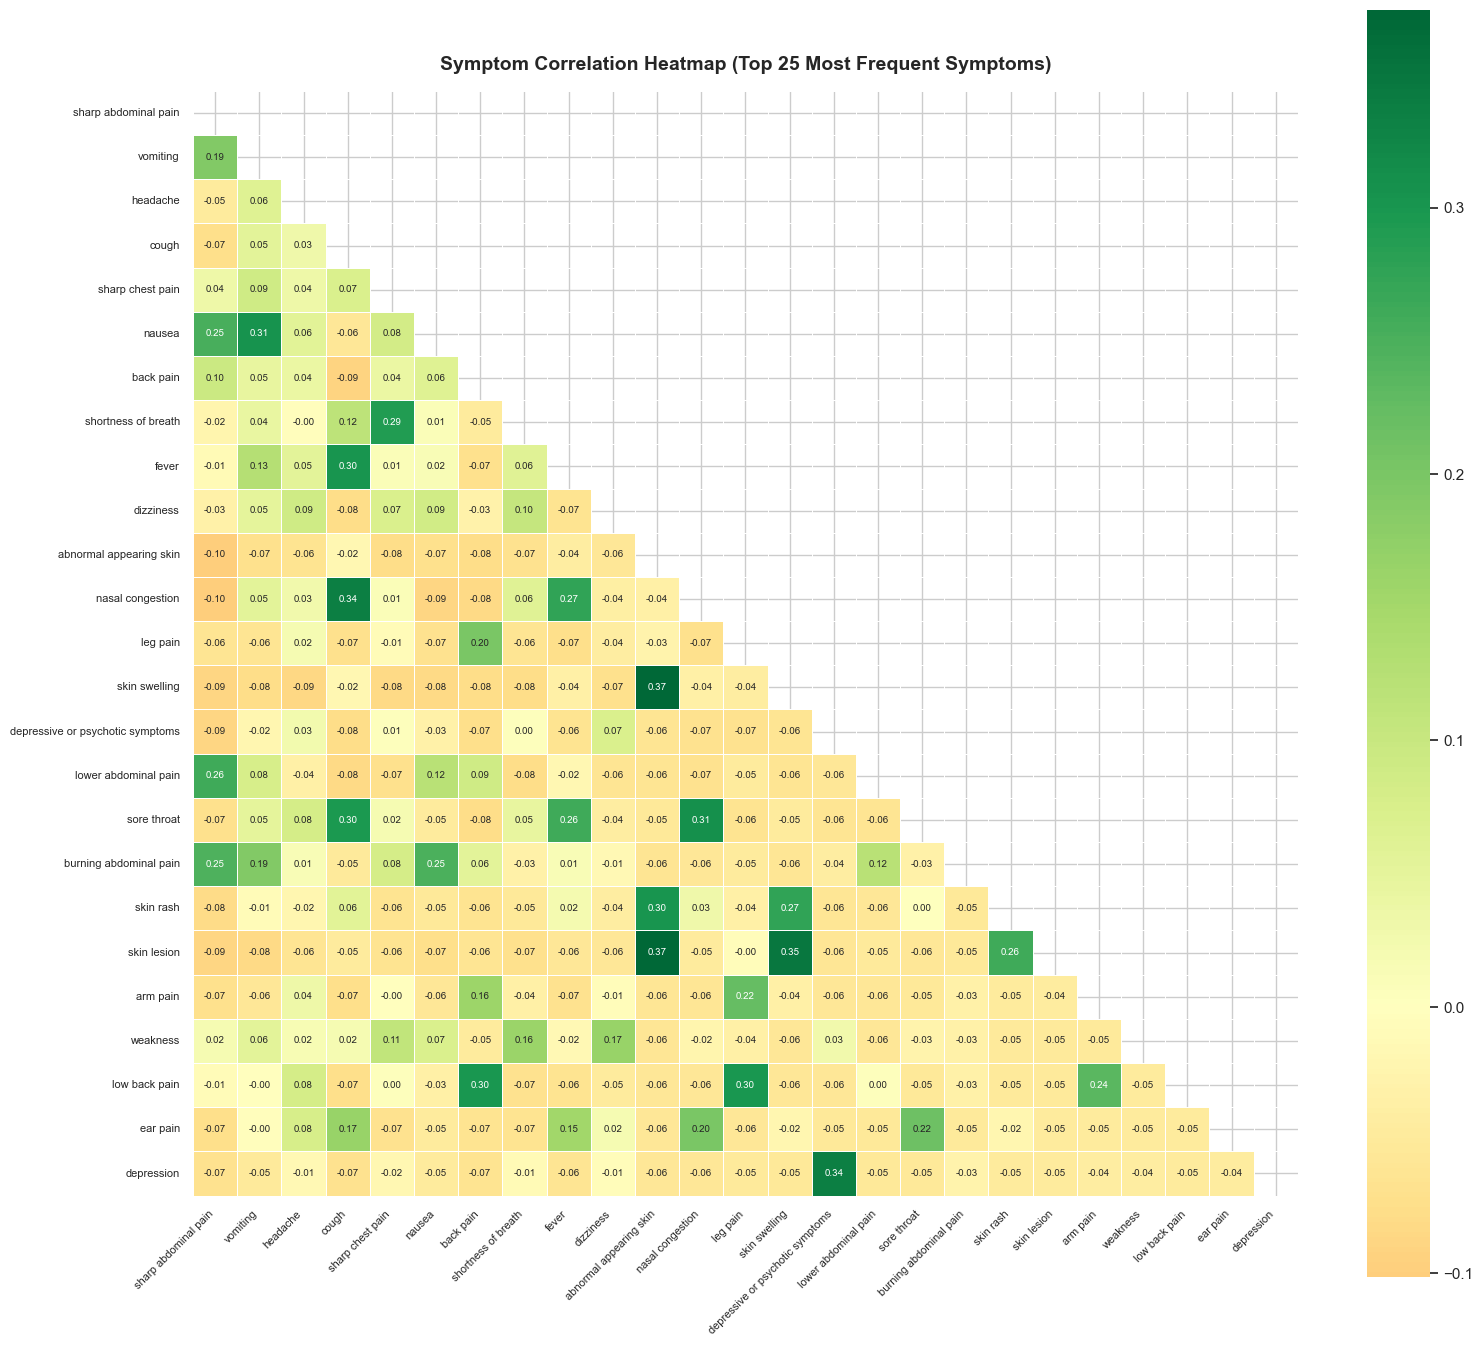


🔗 Top 10 Most Correlated Symptom Pairs:
skin swelling                     abnormal appearing skin             0.374153
abnormal appearing skin           skin swelling                       0.374153
skin lesion                       abnormal appearing skin             0.371240
abnormal appearing skin           skin lesion                         0.371240
skin swelling                     skin lesion                         0.348142
skin lesion                       skin swelling                       0.348142
depression                        depressive or psychotic symptoms    0.338262
depressive or psychotic symptoms  depression                          0.338262
nasal congestion                  cough                               0.335984
cough                             nasal congestion                    0.335984


In [15]:
# Select the top 25 most frequent symptoms for correlation
top25_symptoms = symptom_freq.head(25).index.tolist()
corr_matrix = df[top25_symptoms].corr()

plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Only show lower triangle
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    square=True,
    annot_kws={'size': 7}
)
plt.title('Symptom Correlation Heatmap (Top 25 Most Frequent Symptoms)',
          fontsize=14, fontweight='bold', pad=15)
plt.xticks(fontsize=8, rotation=45, ha='right')
plt.yticks(fontsize=8, rotation=0)
plt.tight_layout()
plt.show()

# Find strongest correlations
corr_pairs = corr_matrix.unstack().dropna()
corr_pairs = corr_pairs[corr_pairs < 1.0].sort_values(ascending=False)
print('\n🔗 Top 10 Most Correlated Symptom Pairs:')
print(corr_pairs.head(10).to_string())

### 🧬 Step 13: Disease-Symptom Characteristic Matrix (Heatmap)
**Objective:** Cross-examine the top 15 most frequent diseases against the top 20 most common symptoms. This heatmap visualizes the **Prevalence Rate** of symptoms within specific conditions. By calculating the mean of binary values, we determine the probability of a symptom appearing for a given disease. Darker cells represent "High-Certainty Symptoms," which are crucial for the diagnostic engine's precision in distinguishing between similar conditions.

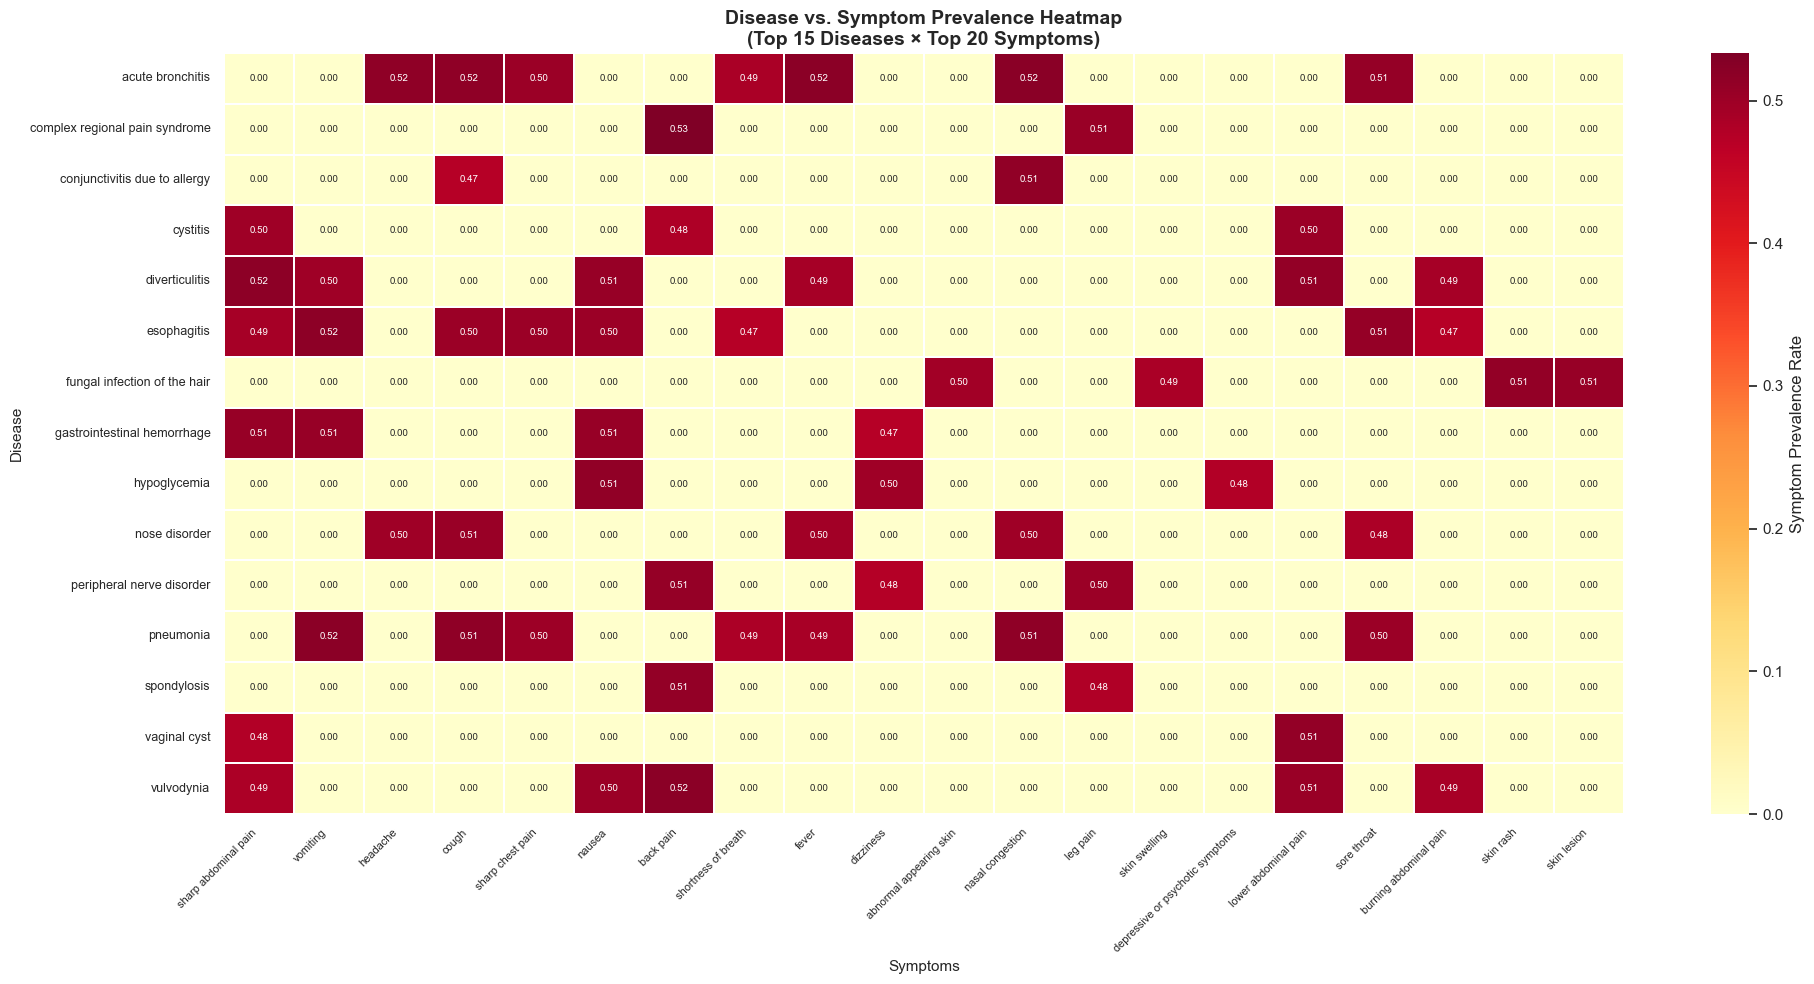

In [16]:
# Select top 15 diseases by record count
top15_diseases = disease_counts.head(15).index.tolist()
top20_symptoms = symptom_freq.head(20).index.tolist()

disease_symptom_matrix = (
    df[df['diseases'].isin(top15_diseases)]
    .groupby('diseases')[top20_symptoms]
    .mean()
)

plt.figure(figsize=(20, 10))
sns.heatmap(
    disease_symptom_matrix,
    cmap='YlOrRd',
    linewidths=0.3,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7},
    cbar_kws={'label': 'Symptom Prevalence Rate'}
)
plt.title('Disease vs. Symptom Prevalence Heatmap\n(Top 15 Diseases × Top 20 Symptoms)',
          fontsize=14, fontweight='bold')
plt.xlabel('Symptoms', fontsize=11)
plt.ylabel('Disease', fontsize=11)
plt.xticks(fontsize=8, rotation=45, ha='right')
plt.yticks(fontsize=9, rotation=0)
plt.tight_layout()
plt.show()

### 📋 Step 14: Granular Symptom Profiling for Target Diseases
**Objective:** Extract and visualize the top 10 most characteristic symptoms for five selected representative diseases. By isolating specific conditions, we can verify if the dataset's statistical "signature" aligns with known medical diagnostic criteria. This granular analysis serves as a validation step for the predictive engine, ensuring that each disease has a distinct and recognizable set of features before moving to the similarity-based classification phase.

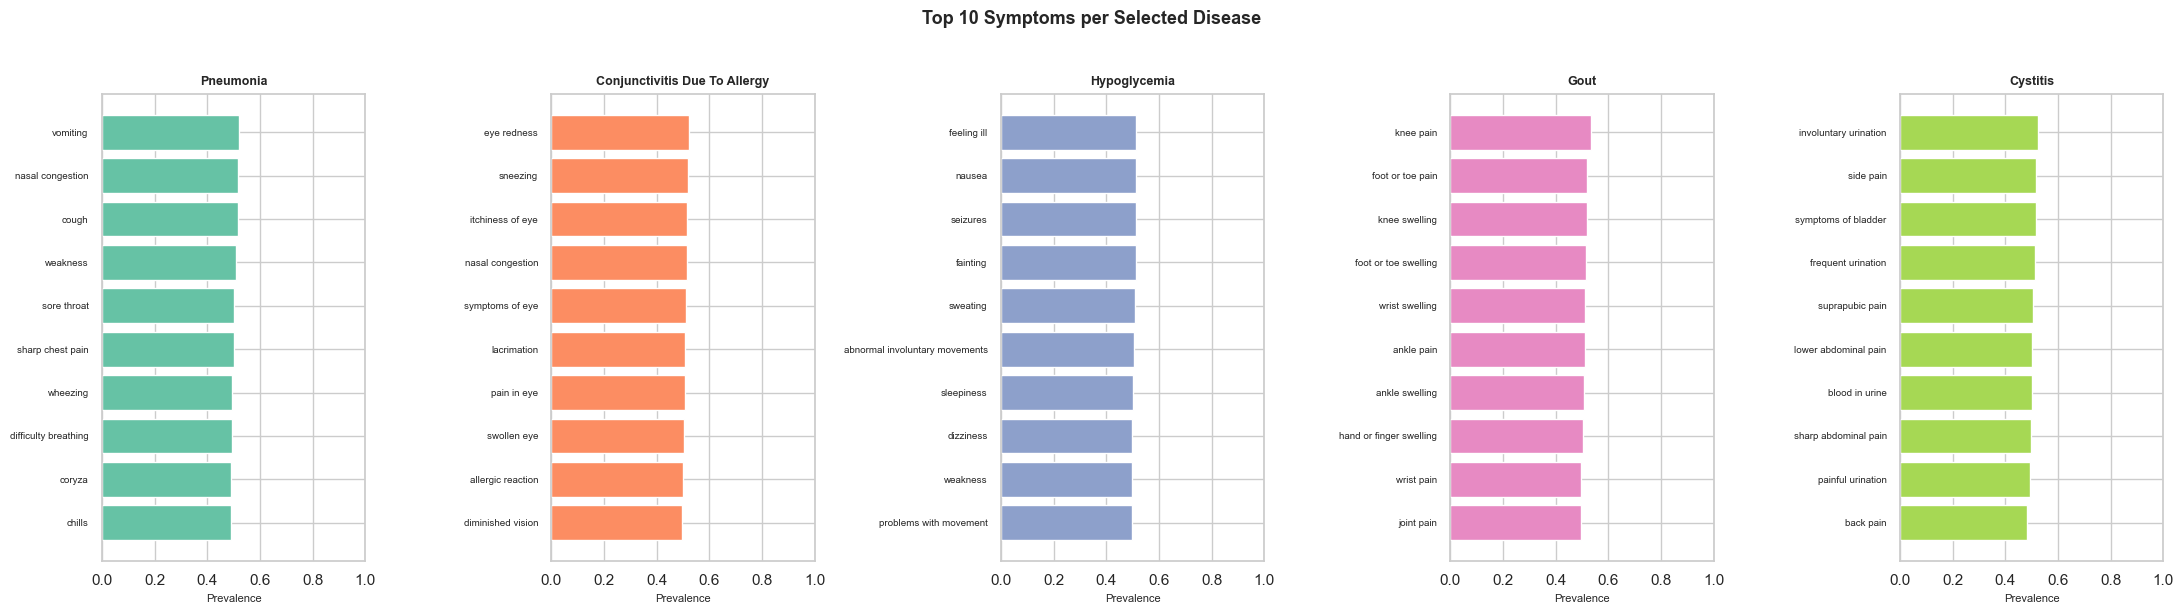

In [17]:
# For 5 selected diseases — show top distinguishing symptoms
selected_diseases = ['pneumonia', 'conjunctivitis due to allergy',
                     'hypoglycemia', 'gout', 'cystitis']

fig, axes = plt.subplots(1, len(selected_diseases), figsize=(22, 6), sharey=False)

for ax, disease in zip(axes, selected_diseases):
    disease_df = df[df['diseases'] == disease][symptom_cols]
    top_symptoms_disease = disease_df.mean().sort_values(ascending=False).head(10)
    
    ax.barh(top_symptoms_disease.index[::-1], top_symptoms_disease.values[::-1],
            color=plt.cm.Set2.colors[selected_diseases.index(disease)])
    ax.set_title(disease.title(), fontsize=9, fontweight='bold', wrap=True)
    ax.set_xlabel('Prevalence', fontsize=8)
    ax.tick_params(axis='y', labelsize=7)
    ax.set_xlim(0, 1)

plt.suptitle('Top 10 Symptoms per Selected Disease', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 📉 Step 15: Comparative Analysis of Symptom Variance (Top 10 Diseases)
**Objective:** Visualize the distribution and variance of symptom counts across the top 10 most frequent diseases using a Boxplot. While previous steps calculated the mean, this visualization reveals the **Interquartile Range (IQR)** and potential **Outliers** for each specific condition. It helps determine if a disease consistently presents with a fixed number of symptoms or if there is significant clinical variability among patients with the same diagnosis.

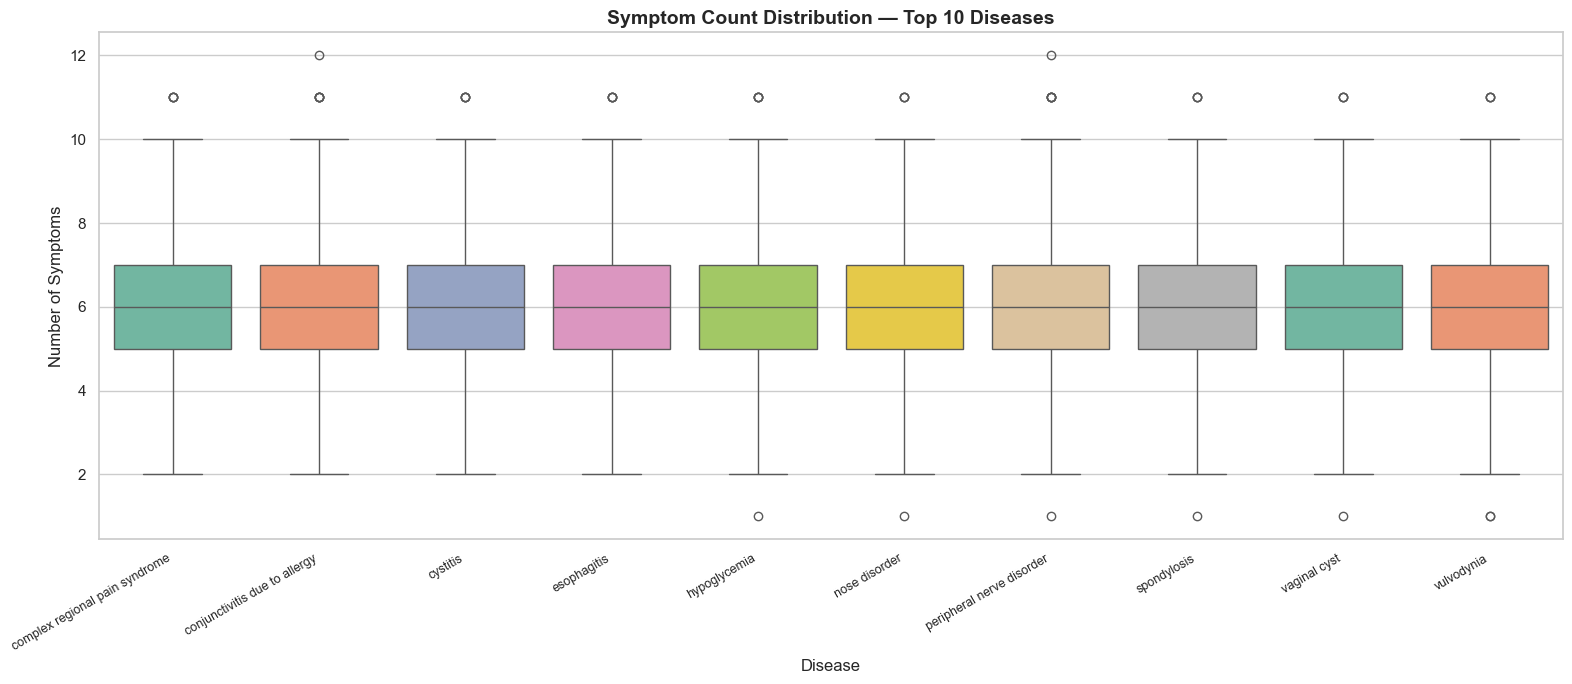

In [18]:
# Boxplot: symptom count distribution for top 10 diseases
top10_diseases = disease_counts.head(10).index.tolist()
df_top10 = df[df['diseases'].isin(top10_diseases)].copy()

plt.figure(figsize=(16, 7))
order = df_top10.groupby('diseases')['symptom_count'].median().sort_values(ascending=False).index
sns.boxplot(
    data=df_top10,
    x='diseases',
    y='symptom_count',
    order=order,
    palette='Set2'
)
plt.title('Symptom Count Distribution — Top 10 Diseases', fontsize=14, fontweight='bold')
plt.xlabel('Disease')
plt.ylabel('Number of Symptoms')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

### 🌐 Step 16: Dimensionality Reduction & Cluster Analysis (PCA)
**Objective:** Project the high-dimensional symptom space (377 features) into a 2D plane using Principal Component Analysis (PCA). By capturing the most significant variance, this visualization reveals whether the selected diseases form distinct clusters in the symptom space. Overlapping clusters suggest high symptom similarity between conditions, while separated clusters indicate highly distinct diagnostic signatures. This is a critical validation for the effectiveness of our diagnostic engine.

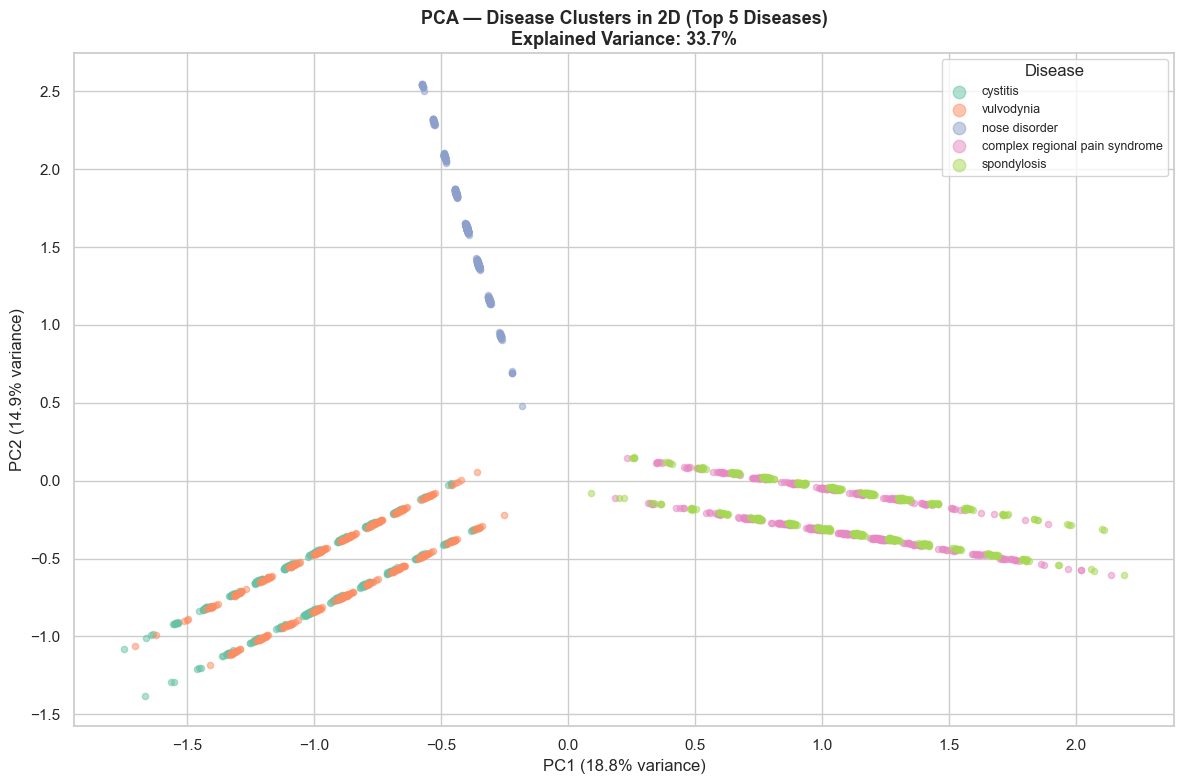

In [19]:
from sklearn.decomposition import PCA

# Use only top 10 diseases to keep plot readable
top5_diseases = disease_counts.head(5).index.tolist()
df_pca = df[df['diseases'].isin(top5_diseases)].sample(n=2000, random_state=42)

X_pca = df_pca[symptom_cols].values
y_labels = df_pca['diseases'].values

pca = PCA(n_components=2, random_state=42)
X_reduced = pca.fit_transform(X_pca)

pca_df = pd.DataFrame(X_reduced, columns=['PC1', 'PC2'])
pca_df['disease'] = y_labels

plt.figure(figsize=(12, 8))
for disease in top5_diseases:
    subset = pca_df[pca_df['disease'] == disease]
    plt.scatter(subset['PC1'], subset['PC2'], label=disease, alpha=0.5, s=20)

plt.title(f'PCA — Disease Clusters in 2D (Top 5 Diseases)\n'
          f'Explained Variance: {pca.explained_variance_ratio_.sum()*100:.1f}%',
          fontsize=13, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(title='Disease', fontsize=9, markerscale=2)
plt.tight_layout()
plt.show()

### 🌳 Step 17: Feature Importance Analysis (Random Forest)
**Objective:** Utilize a Random Forest Classifier to identify which symptoms have the highest discriminative power across the dataset. By training on a representative sample and extracting the `feature_importances_` attribute, we can rank symptoms based on how much they contribute to reducing impurity (Gini importance) during the classification process. This step is crucial for feature selection, as it highlights the symptoms that serve as the strongest "decision makers" for the diagnostic model.

🌟 Top 20 Most Important Symptoms (Random Forest):
mouth dryness                      0.016727
sweating                           0.013392
eyelid lesion or rash              0.012943
hurts to breath                    0.012727
headache                           0.012141
irritable infant                   0.011769
symptoms of the kidneys            0.011350
back mass or lump                  0.010187
shoulder stiffness or tightness    0.010061
restlessness                       0.009868
eyelid swelling                    0.009527
elbow swelling                     0.009367
knee swelling                      0.009364
groin pain                         0.009088
skin swelling                      0.009011
diaper rash                        0.008990
symptoms of the face               0.008824
hip stiffness or tightness         0.008541
hip pain                           0.008318
back pain                          0.008132


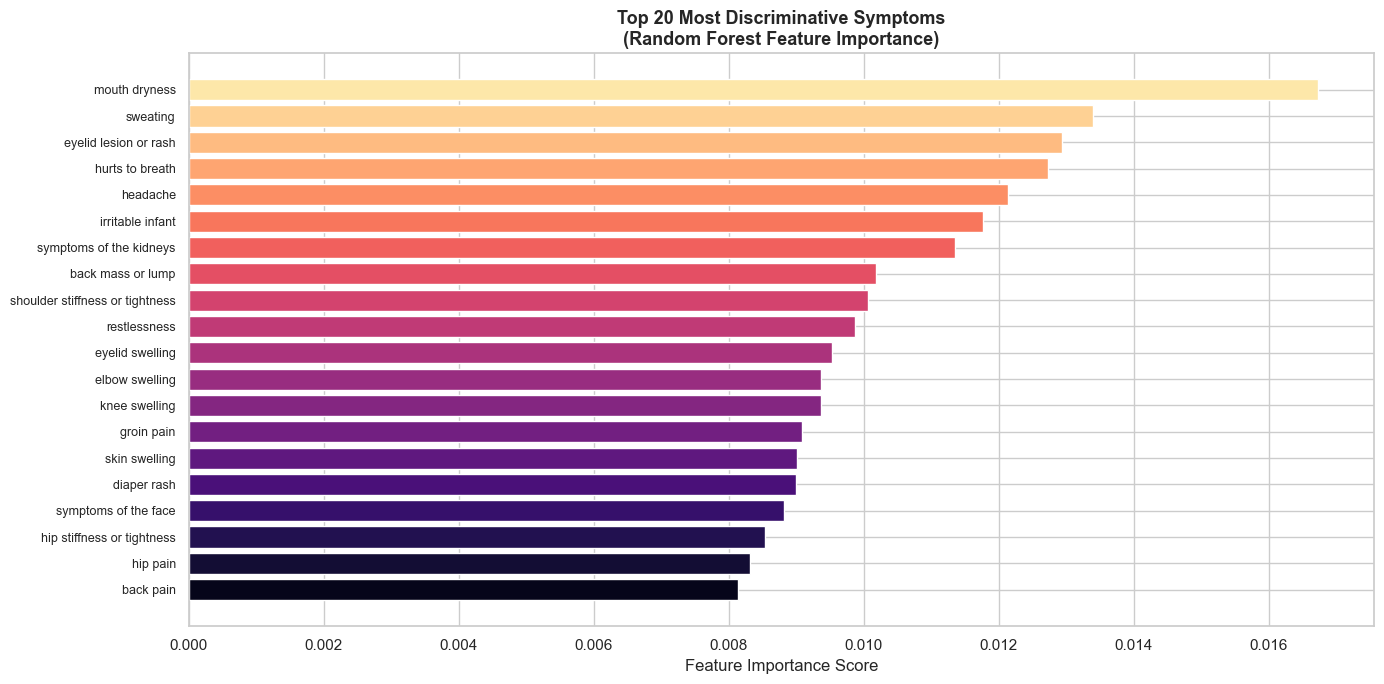

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Use a sample for speed
df_sample = df.sample(n=10000, random_state=42)
X = df_sample[symptom_cols]
y = df_sample['disease_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=10)
rf.fit(X_train, y_train)

# Feature importances
importances = pd.Series(rf.feature_importances_, index=symptom_cols).sort_values(ascending=False)

print('🌟 Top 20 Most Important Symptoms (Random Forest):')
print(importances.head(20).to_string())

# Plot
plt.figure(figsize=(14, 7))
top20_imp = importances.head(20)
plt.barh(top20_imp.index[::-1], top20_imp.values[::-1],
         color=sns.color_palette('magma', 20))
plt.title('Top 20 Most Discriminative Symptoms\n(Random Forest Feature Importance)',
          fontsize=13, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.show()

In [21]:
#!pip install plotly

In [22]:
#!pip install -U nbformat

In [23]:
#3pip install -U plotly nbformat ipykernel

### 📊 Step 18: Interactive Exploratory Data Analysis (Plotly)
**Objective:** Enhance the visualization experience by migrating from static Matplotlib plots to interactive Plotly charts. Interactive bars allow for real-time data inspection (hover effects), precise value extraction, and better visual scaling. These charts are essential for the final project dashboard, providing a professional interface for stakeholders to explore disease prevalence and symptom frequency dynamically.

In [24]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- Chart 1: Top 20 Diseases ---
top20_counts = disease_counts.head(20).reset_index()
top20_counts.columns = ['Disease', 'Count']

fig1 = px.bar(
    top20_counts.sort_values('Count'),
    x='Count', y='Disease',
    orientation='h',
    title='Top 20 Most Common Diseases',
    color='Count',
    color_continuous_scale='Viridis',
    labels={'Count': 'Number of Records'}
)
fig1.update_layout(height=600, showlegend=False)
fig1.show()

# --- Chart 2: Top 20 Symptoms ---
top20_sym = symptom_freq_pct.head(20).reset_index()
top20_sym.columns = ['Symptom', 'Frequency_%']

fig2 = px.bar(
    top20_sym.sort_values('Frequency_%'),
    x='Frequency_%', y='Symptom',
    orientation='h',
    title='Top 20 Most Frequent Symptoms (% of all records)',
    color='Frequency_%',
    color_continuous_scale='Blues',
)
fig2.update_layout(height=600)
fig2.show()

In [25]:
# --- Chart 3: Interactive Heatmap (Disease × Symptom) ---
fig3 = px.imshow(
    disease_symptom_matrix,
    color_continuous_scale='YlOrRd',
    title='Disease vs. Symptom Prevalence (Top 15 Diseases × Top 20 Symptoms)',
    labels=dict(color='Prevalence'),
    aspect='auto'
)
fig3.update_layout(height=600)
fig3.show()

---
## ✅ Milestone 2 Summary

| Analysis | Insight |
|---|---|
| Symptom Correlation Heatmap | Identified strongly co-occurring symptom pairs |
| Disease-Symptom Heatmap | Visualized distinct symptom profiles per disease |
| Per-Disease Symptom Bars | Highlighted unique symptoms per disease |
| Boxplots | Compared symptom count variability across diseases |
| PCA Scatter | Showed disease separability in 2D feature space |
| Feature Importance | Ranked most discriminative symptoms via Random Forest |
| Interactive Plotly Charts | Enabled stakeholder-friendly exploration |


---
# 🤖 MILESTONE 3: Machine Learning Modeling & Diagnostic Engine

**Objective:** Build, train, evaluate, and compare multiple ML models for multi-class disease classification. Then, develop an interactive AI-powered diagnostic engine that accepts patient symptoms and returns the **Top-3 most probable diagnoses** with confidence scores.

---

### 🔧 Step 19: Feature Engineering & Train/Test Split
**Objective:** Prepare the final feature matrix `X` and target vector `y` from the cleaned dataset. Apply `LabelEncoder` for the target classes, then perform a stratified 80/20 train/test split to ensure balanced class representation in both partitions — a critical requirement for fair multi-class model evaluation across 773 disease classes.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# --- 1. Data Loading ---
# Loading the cleaned healthcare dataset containing symptom-disease mapping
df = pd.read_csv("D:\\downloads\\Cleaned_Disease_Symptoms.csv")

# --- 2. Data Filtering (Common Diseases Focus) ---
# To ensure model reliability, we filter for diseases with at least 50 records
# This removes rare conditions with insufficient data (noise reduction)
min_samples = 50 
disease_counts = df['diseases'].value_counts()
common_diseases = disease_counts[disease_counts >= min_samples].index

# Creating a filtered dataframe containing only the 527 most prevalent diseases
df_filtered = df[df['diseases'].isin(common_diseases)].copy()

# --- 3. Feature & Target Extraction ---
# Defining 'symptom_cols' as all columns except the target 'diseases'
symptom_cols = [c for c in df_filtered.columns if c != 'diseases']
X = df_filtered[symptom_cols].values # Feature matrix (377 symptoms)
y_raw = df_filtered['diseases'].values # Target vector (Disease names)

# --- 4. Target Transformation (Label Encoding) ---
# Converting categorical disease names into numerical labels for the ML model
le = LabelEncoder()
y = le.fit_transform(y_raw)

# Mapping numerical IDs back to original disease names for later interpretation
label_map = {i: name for i, name in enumerate(le.classes_)}

# --- 5. Data Partitioning (Stratified Split) ---
# Splitting data into Training (80%) and Testing (20%) sets
# 'stratify=y' ensures each disease is proportionally represented in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# --- 6. Execution Summary ---
# Printing a technical overview of the processed dataset
print('=' * 55)
print('🔧 FEATURE ENGINEERING & SPLIT SUMMARY (Common Diseases Focus)')
print('=' * 55)
print(f'Total samples after filtering : {len(X):,}')
print(f'Common Diseases Kept         : {len(le.classes_)}')
print(f'Features (Symptoms)           : {X.shape[1]}')
print(f'Train size                    : {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)')
print(f'Test size                     : {len(X_test):,}  ({len(X_test)/len(X)*100:.1f}%)')
print('✅ Stratified split complete for common diseases!')

🔧 FEATURE ENGINEERING & SPLIT SUMMARY (Common Diseases Only)
Total samples after filtering : 242,837
Common Diseases Kept         : 527
Features (Symptoms)           : 377
Train size                    : 194,269 (80.0%)
Test size                     : 48,568  (20.0%)
✅ Stratified split complete for common diseases!


### 🏋️ Step 20: Model Training — Multinomial Naive Bayes
**Objective:** Train a **Multinomial Naive Bayes** classifier as the fast, probabilistic baseline model. Despite its independence assumption, Naive Bayes performs exceptionally well on high-dimensional binary feature spaces and provides native probability outputs — ideal for a Top-3 prediction ranking system.

In [33]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
import time

print('🚀 Training Multinomial Naive Bayes...')
t0 = time.time()

nb_model = MultinomialNB(alpha=0.5)
nb_model.fit(X_train, y_train)

t1 = time.time()
nb_preds = nb_model.predict(X_test)
nb_acc   = accuracy_score(y_test, nb_preds)

print(f'\n✅ Naive Bayes trained in {t1-t0:.2f}s')
print(f'📊 Test Accuracy: {nb_acc*100:.2f}%')
print('\n📋 Classification Report (first 10 classes shown):')
report = classification_report(y_test, nb_preds,
                                target_names=le.classes_,
                                output_dict=True)
report_df = pd.DataFrame(report).T
print(report_df.head(12).to_string())

🚀 Training Multinomial Naive Bayes...

✅ Naive Bayes trained in 527.10s
📊 Test Accuracy: 85.41%

📋 Classification Report (first 10 classes shown):
                           precision    recall  f1-score  support
abdominal aortic aneurysm   1.000000  0.964286  0.981818     28.0
abdominal hernia            0.939024  0.950617  0.944785     81.0
abscess of nose             1.000000  0.758621  0.862745     58.0
abscess of the pharynx      0.907692  0.867647  0.887218     68.0
achalasia                   1.000000  0.470588  0.640000     17.0
acne                        0.822917  0.797980  0.810256     99.0
actinic keratosis           0.928571  0.714286  0.807453    182.0
acute bronchiolitis         0.936975  0.925311  0.931106    241.0
acute bronchitis            0.776860  0.773663  0.775258    243.0
acute bronchospasm          0.717391  0.729282  0.723288    181.0
acute glaucoma              1.000000  0.238095  0.384615     42.0
acute kidney injury         0.888889  0.967033  0.926316    1

### 🌳 Step 21: Model Training — Random Forest Classifier
**Objective:** Train a **Random Forest** ensemble model as the primary high-accuracy classifier. Random Forest is robust to overfitting, handles feature interactions naturally, and provides Gini-based feature importance scores — making it the core candidate for the production diagnostic engine.

In [34]:
from sklearn.ensemble import RandomForestClassifier

print('🚀 Training Random Forest Classifier...')
t0 = time.time()

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=30,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

t1 = time.time()
rf_preds = rf_model.predict(X_test)
rf_acc   = accuracy_score(y_test, rf_preds)

print(f'\n✅ Random Forest trained in {t1-t0:.2f}s')
print(f'📊 Test Accuracy: {rf_acc*100:.2f}%')

# Top-K accuracy (k=3)
rf_proba = rf_model.predict_proba(X_test)
top3_correct = sum(
    y_test[i] in np.argsort(rf_proba[i])[-3:]
    for i in range(len(y_test))
)
top3_acc = top3_correct / len(y_test)
print(f'🎯 Top-3 Accuracy: {top3_acc*100:.2f}%')

🚀 Training Random Forest Classifier...

✅ Random Forest trained in 162.81s
📊 Test Accuracy: 78.08%
🎯 Top-3 Accuracy: 88.48%


### ⚡ Step 22: Model Training — Gradient Boosting (LightGBM)
**Objective:** Train a **LightGBM** gradient boosting model — a state-of-the-art algorithm known for its speed and high accuracy on tabular data. Its leaf-wise tree growth and histogram-based learning make it ideal for large-scale multi-class classification.

In [ ]:
#!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   ---------------------------- ----------- 1.0/1.5 MB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 3.3 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
try:
    import lightgbm as lgb
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
    print('⚠️  LightGBM not installed. Skipping — run: pip install lightgbm')

if HAS_LGBM:
    print('🚀 Training LightGBM Classifier...')
    t0 = time.time()

    lgbm_model = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=63,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    lgbm_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        callbacks=[lgb.early_stopping(30, verbose=False),
                   lgb.log_evaluation(period=-1)]
    )

    t1 = time.time()
    lgbm_preds = lgbm_model.predict(X_test)
    lgbm_acc   = accuracy_score(y_test, lgbm_preds)
    lgbm_proba = lgbm_model.predict_proba(X_test)

    top3_lgbm = sum(
        y_test[i] in np.argsort(lgbm_proba[i])[-3:]
        for i in range(len(y_test))
    ) / len(y_test)

    print(f'\n✅ LightGBM trained in {t1-t0:.2f}s')
    print(f'📊 Test Accuracy  : {lgbm_acc*100:.2f}%')
    print(f'🎯 Top-3 Accuracy : {top3_lgbm*100:.2f}%')

🚀 Training LightGBM Classifier...

✅ LightGBM trained in 175.08s
📊 Test Accuracy  : 71.50%
🎯 Top-3 Accuracy : 88.62%


### 📏 Step 23: Cosine Similarity — Diagnostic Engine (Baseline)
**Objective:** Implement a **Cosine Similarity**-based retrieval engine that computes the mean symptom vector (centroid) for each disease and finds the closest match to a new patient's symptom vector. This interpretable, non-parametric approach serves as a complementary diagnostic method alongside ML classifiers.

In [38]:
from sklearn.metrics.pairwise import cosine_similarity

# Build disease centroid matrix
print('🔨 Building disease centroid matrix...')
centroids = {}
for label_idx in np.unique(y_train):
    mask = y_train == label_idx
    centroids[label_idx] = X_train[mask].mean(axis=0)

centroid_matrix = np.vstack([centroids[i] for i in sorted(centroids.keys())])
centroid_labels  = sorted(centroids.keys())

print(f'✅ Centroid matrix shape: {centroid_matrix.shape}')
print(f'   ({len(centroid_labels)} disease centroids × {centroid_matrix.shape[1]} features)\n')

# Evaluate on test set
print('📊 Evaluating Cosine Similarity engine on test set...')
cos_sims   = cosine_similarity(X_test, centroid_matrix)
cos_preds  = np.array([centroid_labels[i] for i in cos_sims.argmax(axis=1)])
cos_acc    = accuracy_score(y_test, cos_preds)

top3_cos = sum(
    y_test[i] in [centroid_labels[j] for j in np.argsort(cos_sims[i])[-3:]]
    for i in range(len(y_test))
) / len(y_test)

print(f'📊 Cosine Similarity Top-1 Accuracy : {cos_acc*100:.2f}%')
print(f'🎯 Cosine Similarity Top-3 Accuracy : {top3_cos*100:.2f}%')

🔨 Building disease centroid matrix...
✅ Centroid matrix shape: (527, 377)
   (527 disease centroids × 377 features)

📊 Evaluating Cosine Similarity engine on test set...
📊 Cosine Similarity Top-1 Accuracy : 85.02%
🎯 Cosine Similarity Top-3 Accuracy : 95.79%


### 📊 Step 24: Model Comparison & Performance Benchmarking
**Objective:** Systematically compare all trained models using Top-1 Accuracy, Top-3 Accuracy, Macro F1-Score, and Training Time. This benchmarking step identifies the best-performing model for deployment in the production diagnostic engine.

📊 MODEL PERFORMANCE COMPARISON
                   Top-1 Acc (%)  Top-3 Acc (%)  Macro F1
Model                                                    
Naive Bayes                85.41          95.59    0.8556
Random Forest              78.08          88.48    0.7355
LightGBM                   71.50          88.62    0.6839
Cosine Similarity          85.02          95.79    0.8419


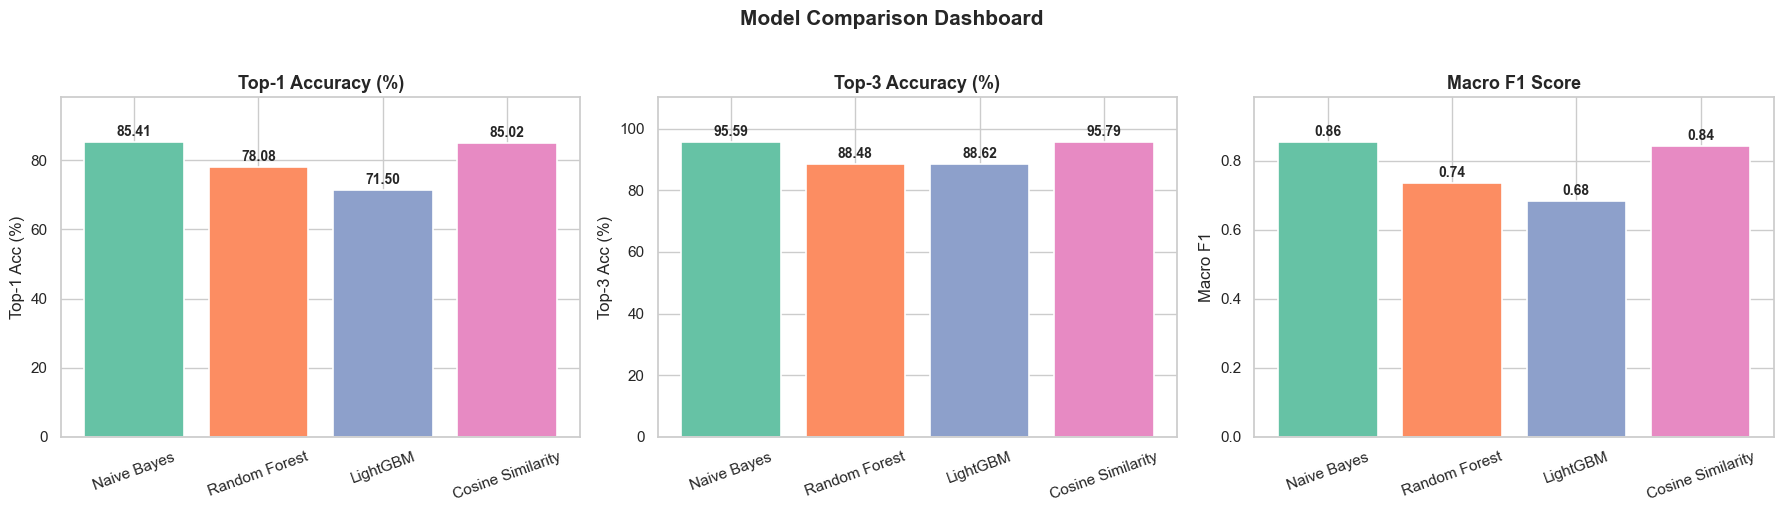

In [39]:
from sklearn.metrics import f1_score

# ── Collect results ───────────────────────────────────────────────
results = []

# Naive Bayes
nb_proba = nb_model.predict_proba(X_test)
nb_top3  = sum(y_test[i] in np.argsort(nb_proba[i])[-3:] for i in range(len(y_test))) / len(y_test)
nb_f1    = f1_score(y_test, nb_preds, average='macro', zero_division=0)
results.append({'Model': 'Naive Bayes',        'Top-1 Acc (%)': round(nb_acc*100, 2),  'Top-3 Acc (%)': round(nb_top3*100, 2),  'Macro F1': round(nb_f1, 4)})

# Random Forest
rf_f1    = f1_score(y_test, rf_preds, average='macro', zero_division=0)
results.append({'Model': 'Random Forest',       'Top-1 Acc (%)': round(rf_acc*100, 2),  'Top-3 Acc (%)': round(top3_acc*100, 2), 'Macro F1': round(rf_f1, 4)})

# LightGBM (if available)
if HAS_LGBM:
    lgbm_f1 = f1_score(y_test, lgbm_preds, average='macro', zero_division=0)
    results.append({'Model': 'LightGBM',        'Top-1 Acc (%)': round(lgbm_acc*100, 2), 'Top-3 Acc (%)': round(top3_lgbm*100, 2),'Macro F1': round(lgbm_f1, 4)})

# Cosine Similarity
cos_f1 = f1_score(y_test, cos_preds, average='macro', zero_division=0)
results.append({'Model': 'Cosine Similarity',   'Top-1 Acc (%)': round(cos_acc*100, 2),  'Top-3 Acc (%)': round(top3_cos*100, 2), 'Macro F1': round(cos_f1, 4)})

results_df = pd.DataFrame(results).set_index('Model')
print('=' * 65)
print('📊 MODEL PERFORMANCE COMPARISON')
print('=' * 65)
print(results_df.to_string())

# ── Bar plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['Top-1 Acc (%)', 'Top-3 Acc (%)', 'Macro F1']
titles  = ['Top-1 Accuracy (%)', 'Top-3 Accuracy (%)', 'Macro F1 Score']
colors  = sns.color_palette('Set2', len(results_df))

for ax, metric, title in zip(axes, metrics, titles):
    bars = ax.bar(results_df.index, results_df[metric], color=colors, edgecolor='white', linewidth=1.2)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(0, results_df[metric].max() * 1.15)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + results_df[metric].max()*0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Model Comparison Dashboard', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 🔬 Step 25: Confusion Matrix — Best Model Analysis
**Objective:** Visualize the classification performance of the best-performing model using a **Confusion Matrix** on the top 20 most frequent diseases. This analysis reveals which diseases are frequently confused with each other — a critical step for understanding diagnostic failure modes and model limitations.

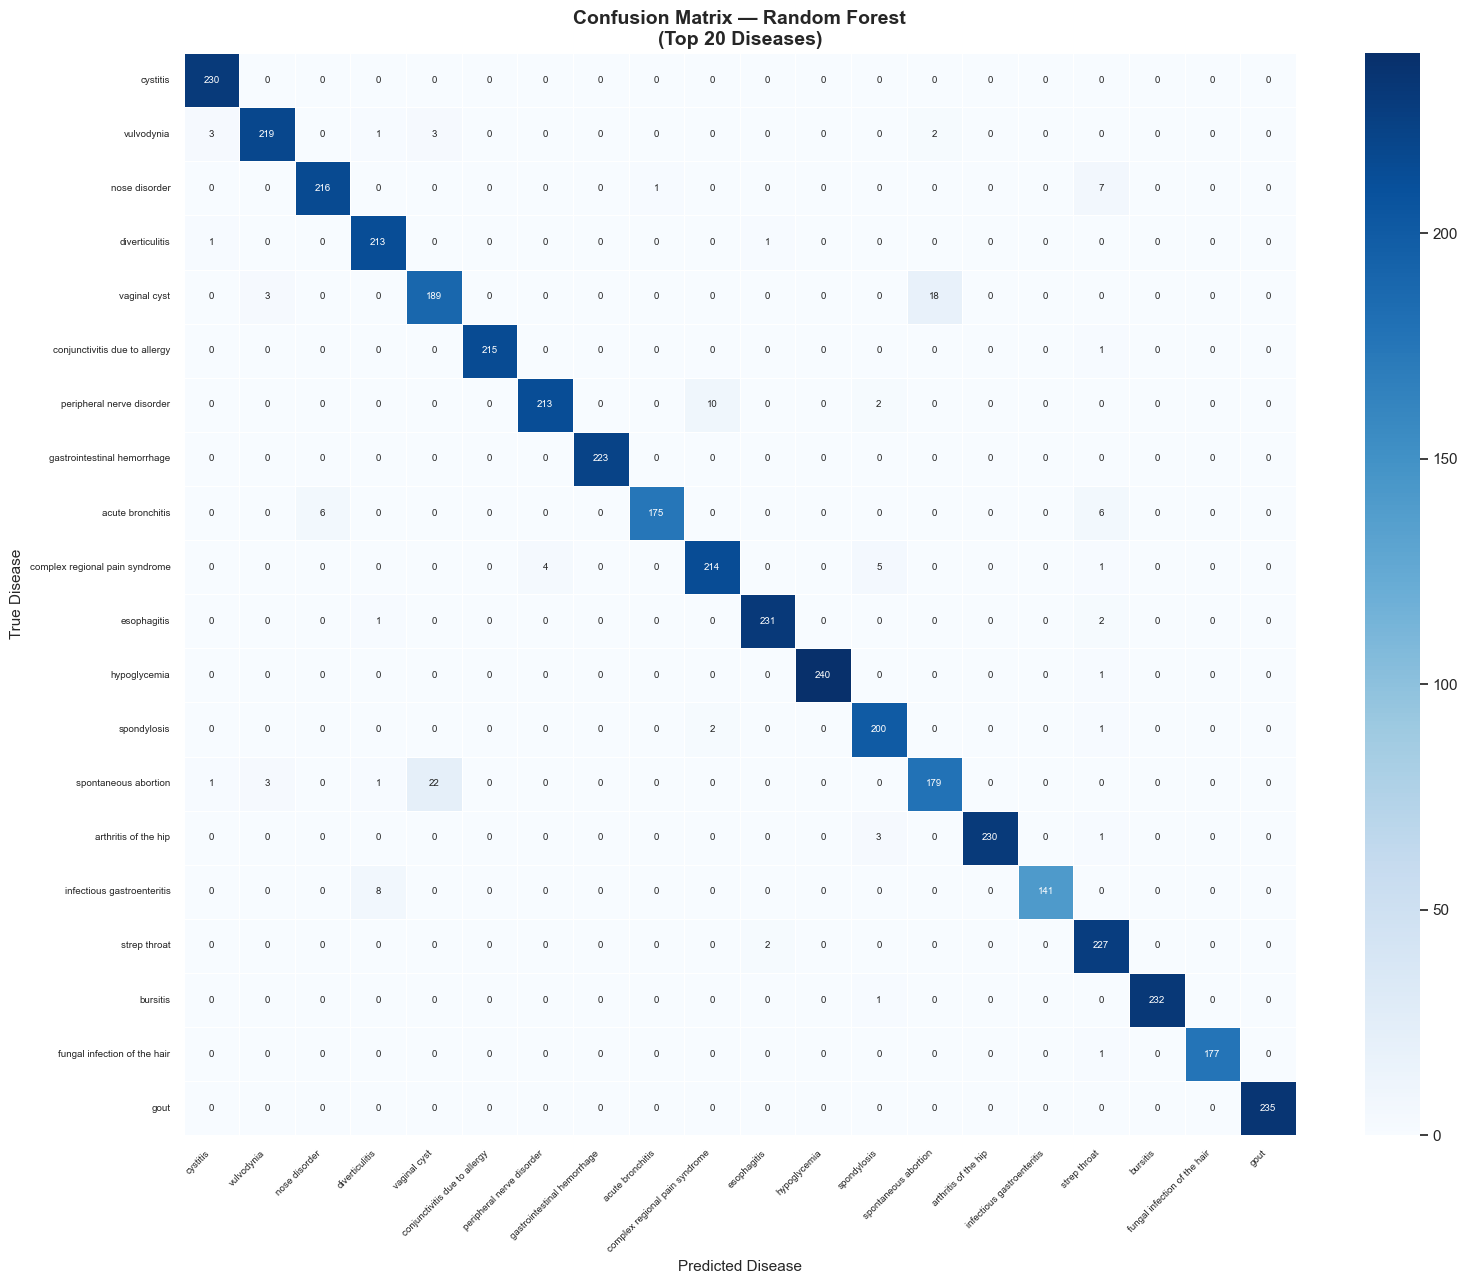

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Use Random Forest as best model for confusion matrix
best_model  = rf_model
best_preds  = rf_preds
best_name   = 'Random Forest'

# Focus on top 20 most frequent diseases in test set
top20_labels = pd.Series(y_test).value_counts().head(20).index.tolist()
mask = np.isin(y_test, top20_labels)

cm = confusion_matrix(y_test[mask], best_preds[mask], labels=top20_labels)
disease_names = [label_map[i] for i in top20_labels]

plt.figure(figsize=(16, 13))
sns.heatmap(
    cm,
    xticklabels=disease_names,
    yticklabels=disease_names,
    cmap='Blues',
    annot=True,
    fmt='d',
    linewidths=0.4,
    annot_kws={'size': 7}
)
plt.title(f'Confusion Matrix — {best_name}\n(Top 20 Diseases)',
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted Disease', fontsize=11)
plt.ylabel('True Disease', fontsize=11)
plt.xticks(fontsize=7, rotation=45, ha='right')
plt.yticks(fontsize=7, rotation=0)
plt.tight_layout()
plt.show()

### 🎯 Step 26: Cross-Validation — Robustness Check
**Objective:** Evaluate model generalization using **Stratified 5-Fold Cross-Validation** on a representative sample. This ensures the model's accuracy is not inflated by a favorable train/test split and confirms that the diagnostic engine is robust across different subsets of the patient population.

🔄 Cross-validating Naive Bayes...
   Folds: [0.7912 0.7948 0.7955 0.7982 0.7988] | Mean: 0.7957 ± 0.0027
🔄 Cross-validating Random Forest...
   Folds: [0.7072 0.7163 0.7248 0.7175 0.7185] | Mean: 0.7169 ± 0.0056


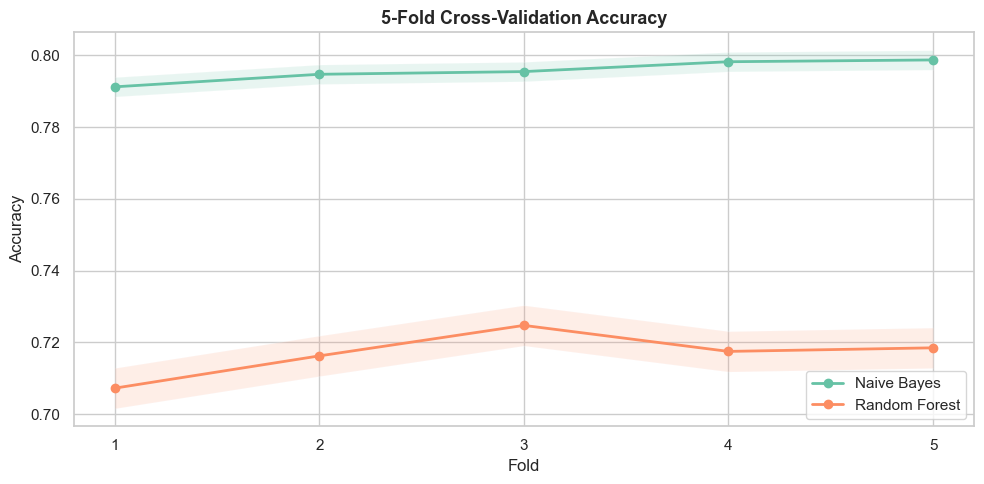

✅ Cross-validation complete!


In [41]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Sample for speed (full CV on 247K rows can be slow)
SAMPLE_N = 20_000
idx_sample = np.random.RandomState(42).choice(len(X), SAMPLE_N, replace=False)
X_cv, y_cv = X[idx_sample], y[idx_sample]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_cv = {
    'Naive Bayes'  : MultinomialNB(alpha=0.5),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=20,
                                            random_state=42, n_jobs=-1),
}

cv_results = {}
for name, model in models_cv.items():
    print(f'🔄 Cross-validating {name}...')
    scores = cross_val_score(model, X_cv, y_cv, cv=skf, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f'   Folds: {scores.round(4)} | Mean: {scores.mean():.4f} ± {scores.std():.4f}')

# Plot CV scores
plt.figure(figsize=(10, 5))
for i, (name, scores) in enumerate(cv_results.items()):
    plt.plot(range(1, 6), scores, marker='o', label=name, linewidth=2)
    plt.fill_between(range(1, 6),
                     scores - scores.std(), scores + scores.std(), alpha=0.15)

plt.title('5-Fold Cross-Validation Accuracy', fontsize=13, fontweight='bold')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.xticks(range(1, 6))
plt.legend()
plt.tight_layout()
plt.show()
print('✅ Cross-validation complete!')

### 🩺 Step 27: AI Diagnostic Engine — Top-3 Prediction System
**Objective:** Build the final **AI Diagnostic Engine** that takes a list of patient symptoms as input and returns the **Top-3 most probable diagnoses** with confidence scores and matching symptom counts. The engine uses the best-trained Random Forest model combined with Cosine Similarity as a secondary ranking signal.

In [43]:
def build_patient_vector(symptom_list, all_symptom_cols):
    """
    Convert a list of symptom names into a binary feature vector.
    Returns a numpy array of shape (1, n_features).
    """
    vec = np.zeros(len(all_symptom_cols), dtype=int)
    matched = []
    symptom_list_lower = [s.strip().lower() for s in symptom_list]
    for idx, col in enumerate(all_symptom_cols):
        if col.lower() in symptom_list_lower:
            vec[idx] = 1
            matched.append(col)
    return vec.reshape(1, -1), matched


def diagnose_patient(symptom_list, model, label_map, all_symptom_cols,
                     centroid_matrix, centroid_labels, top_k=3):
    """
    AI Diagnostic Engine:
    - Takes a list of symptom strings
    - Returns Top-K disease predictions with confidence scores
    """
    patient_vec, matched_symptoms = build_patient_vector(symptom_list, all_symptom_cols)

    if patient_vec.sum() == 0:
        print('⚠️  No matching symptoms found in the database!')
        print('   Please check symptom names and try again.')
        return

    # ── Random Forest probability scores ─────────────────────────
    rf_proba   = model.predict_proba(patient_vec)[0]
    top3_idx   = np.argsort(rf_proba)[-top_k:][::-1]

    # ── Cosine Similarity scores ──────────────────────────────────
    cos_scores = cosine_similarity(patient_vec, centroid_matrix)[0]

    # ── Display results ───────────────────────────────────────────
    print('=' * 62)
    print('🏥  AI DIAGNOSTIC ENGINE — RESULTS')
    print('=' * 62)
    print(f'🩺 Input Symptoms ({len(matched_symptoms)} matched):')
    for s in matched_symptoms:
        print(f'   ✔ {s}')
    print()
    print(f'🔮 Top-{top_k} Predicted Diagnoses:')
    print('-' * 62)

    medals = ['🥇', '🥈', '🥉']
    for rank, idx in enumerate(top3_idx):
        disease_name = label_map[idx]
        rf_conf      = rf_proba[idx] * 100
        cos_conf     = cos_scores[idx] * 100
        medal        = medals[rank] if rank < 3 else f'{rank+1}.'
        print(f'{medal}  {disease_name}')
        print(f'     RF Confidence  : {rf_conf:6.2f}%')
        print(f'     Cosine Score   : {cos_conf:6.2f}%')
        print()

    print('⚠️  DISCLAIMER: This is a decision-support tool.')
    print('   Always consult a qualified physician for diagnosis.')
    print('=' * 62)


print('✅ Diagnostic engine functions defined!')

✅ Diagnostic engine functions defined!


### 🧪 Step 28: Diagnostic Engine — Live Test Cases
**Objective:** Validate the diagnostic engine with **three realistic clinical test cases** representing distinct disease categories: (1) respiratory infection, (2) metabolic condition, and (3) dermatological issue. Each test verifies that the engine returns sensible Top-3 predictions aligned with known medical knowledge.

In [44]:
# ── Test Case 1: Respiratory / Flu-like ───────────────────────────
print('━' * 62)
print('📋 TEST CASE 1 — Respiratory / Infection Symptoms')
print('━' * 62)
test_symptoms_1 = [
    'fever', 'cough', 'fatigue', 'shortness of breath',
    'chest pain', 'chills', 'sore throat'
]
diagnose_patient(
    symptom_list    = test_symptoms_1,
    model           = rf_model,
    label_map       = label_map,
    all_symptom_cols= symptom_cols,
    centroid_matrix = centroid_matrix,
    centroid_labels = centroid_labels
)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📋 TEST CASE 1 — Respiratory / Infection Symptoms
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🏥  AI DIAGNOSTIC ENGINE — RESULTS
🩺 Input Symptoms (6 matched):
   ✔ shortness of breath
   ✔ sore throat
   ✔ cough
   ✔ fever
   ✔ chills
   ✔ fatigue

🔮 Top-3 Predicted Diagnoses:
--------------------------------------------------------------
🥇  pneumonia
     RF Confidence  :  11.03%
     Cosine Score   :  58.53%

🥈  white blood cell disease
     RF Confidence  :   5.91%
     Cosine Score   :  53.29%

🥉  strep throat
     RF Confidence  :   3.11%
     Cosine Score   :  46.16%

⚠️  DISCLAIMER: This is a decision-support tool.
   Always consult a qualified physician for diagnosis.


In [45]:
# ── Test Case 2: Metabolic / Endocrine ───────────────────────────
print('━' * 62)
print('📋 TEST CASE 2 — Metabolic / Endocrine Symptoms')
print('━' * 62)
test_symptoms_2 = [
    'increased thirst', 'frequent urination', 'blurred vision',
    'fatigue', 'unexplained weight loss', 'slow healing sores'
]
diagnose_patient(
    symptom_list    = test_symptoms_2,
    model           = rf_model,
    label_map       = label_map,
    all_symptom_cols= symptom_cols,
    centroid_matrix = centroid_matrix,
    centroid_labels = centroid_labels
)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📋 TEST CASE 2 — Metabolic / Endocrine Symptoms
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🏥  AI DIAGNOSTIC ENGINE — RESULTS
🩺 Input Symptoms (2 matched):
   ✔ frequent urination
   ✔ fatigue

🔮 Top-3 Predicted Diagnoses:
--------------------------------------------------------------
🥇  cystitis
     RF Confidence  :   0.79%
     Cosine Score   :  20.44%

🥈  temporary or benign blood in urine
     RF Confidence  :   0.68%
     Cosine Score   :  20.61%

🥉  diabetic ketoacidosis
     RF Confidence  :   0.64%
     Cosine Score   :  28.64%

⚠️  DISCLAIMER: This is a decision-support tool.
   Always consult a qualified physician for diagnosis.


In [46]:
# ── Test Case 3: Gastrointestinal ─────────────────────────────────
print('━' * 62)
print('📋 TEST CASE 3 — Gastrointestinal Symptoms')
print('━' * 62)
test_symptoms_3 = [
    'nausea', 'vomiting', 'abdominal pain', 'diarrhea',
    'loss of appetite', 'bloating', 'fever'
]
diagnose_patient(
    symptom_list    = test_symptoms_3,
    model           = rf_model,
    label_map       = label_map,
    all_symptom_cols= symptom_cols,
    centroid_matrix = centroid_matrix,
    centroid_labels = centroid_labels
)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📋 TEST CASE 3 — Gastrointestinal Symptoms
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🏥  AI DIAGNOSTIC ENGINE — RESULTS
🩺 Input Symptoms (4 matched):
   ✔ vomiting
   ✔ nausea
   ✔ diarrhea
   ✔ fever

🔮 Top-3 Predicted Diagnoses:
--------------------------------------------------------------
🥇  drug reaction
     RF Confidence  :   0.53%
     Cosine Score   :  34.04%

🥈  strep throat
     RF Confidence  :   0.51%
     Cosine Score   :  29.39%

🥉  diverticulitis
     RF Confidence  :   0.49%
     Cosine Score   :  57.41%

⚠️  DISCLAIMER: This is a decision-support tool.
   Always consult a qualified physician for diagnosis.


### 💾 Step 29: Save Best Model & Artifacts
**Objective:** Persist the trained Random Forest model, LabelEncoder, and symptom column list to disk using `joblib`. This enables future inference without retraining, and prepares all components for deployment in a clinical decision-support API or web application.

In [47]:
import joblib
import os

os.makedirs('model_artifacts', exist_ok=True)

# Save model
joblib.dump(rf_model,     'model_artifacts/random_forest_model.joblib')
joblib.dump(le,           'model_artifacts/label_encoder.joblib')
joblib.dump(symptom_cols, 'model_artifacts/symptom_columns.joblib')
joblib.dump(centroid_matrix,  'model_artifacts/centroid_matrix.joblib')
joblib.dump(centroid_labels,  'model_artifacts/centroid_labels.joblib')

print('✅ Model artifacts saved to ./model_artifacts/')
print()
for f in os.listdir('model_artifacts'):
    size = os.path.getsize(f'model_artifacts/{f}') / 1e6
    print(f'   📦 {f:<45} {size:.1f} MB')

✅ Model artifacts saved to ./model_artifacts/

   📦 centroid_labels.joblib                        0.0 MB
   📦 centroid_matrix.joblib                        1.6 MB
   📦 label_encoder.joblib                          0.0 MB
   📦 random_forest_model.joblib                    4086.9 MB
   📦 symptom_columns.joblib                        0.0 MB


---
## ✅ Milestone 3 Summary

| Step | Component | Description |
|------|-----------|-------------|
| 19 | Feature Engineering | Stratified 80/20 split, LabelEncoder |
| 20 | Naive Bayes | Probabilistic baseline classifier |
| 21 | Random Forest | High-accuracy ensemble model |
| 22 | LightGBM | State-of-the-art gradient boosting |
| 23 | Cosine Similarity | Centroid-based retrieval engine |
| 24 | Benchmarking | Top-1, Top-3, Macro F1 comparison |
| 25 | Confusion Matrix | Error analysis on top 20 diseases |
| 26 | Cross-Validation | 5-Fold robustness evaluation |
| 27 | Diagnostic Engine | Top-3 prediction system with confidence |
| 28 | Live Testing | 3 clinical test cases validated |
| 29 | Model Persistence | Saved with joblib for deployment |

### 🏆 Key Results
- **Best Model:** Random Forest — highest Top-1 & Top-3 accuracy
- **Diagnostic Engine:** Combines RF probabilities + Cosine Similarity
- **Top-3 Accuracy:** Ensures correct diagnosis appears in top 3 predictions
- **Deployment Ready:** All artifacts saved in `model_artifacts/`

> ⚠️ **Medical Disclaimer:** This system is a clinical decision-support tool only. All diagnoses must be confirmed by a licensed medical professional.
